In [157]:
import os
os.environ["ACCELERATE_SKIP_VERSION_CHECK"] = "1"

import torch
import torch.nn as nn
import torch.nn.functional as F

from datasets import load_dataset
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    Trainer, 
    TrainingArguments
)

import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import random
from collections import Counter
import re

In [2]:
dataset = load_dataset("fancyzhx/ag_news")

In [3]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

In [4]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"], 
        padding="max_length", 
        truncation=True, 
        max_length=128
    )

tokenized_datasets = dataset.map(tokenize_function, batched=True)

In [5]:
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", 
    num_labels=4
)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 19556.60it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    logging_steps=100,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"], # Sample down if GPU memory/time is limited
    eval_dataset=tokenized_datasets["test"],
)

In [203]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.243944,0.286499


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.50it/s]


TrainOutput(global_step=313, training_loss=0.26026415901062205, metrics={'train_runtime': 73.5793, 'train_samples_per_second': 135.908, 'train_steps_per_second': 4.254, 'total_flos': 331192120320000.0, 'train_loss': 0.26026415901062205, 'epoch': 1.0})

In [204]:
def get_model_predictions(text_list, model, tokenizer):
    inputs = tokenizer(text_list, padding=True, truncation=True, return_tensors="pt").to(model.device)
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        # Convert raw logits to probabilities via Softmax
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    return probs

# Example Inference
sample_text = ["Tech company releases new AI processor today."]
probabilities = get_model_predictions(sample_text, model, tokenizer)

# Output probabilities and chosen prediction
predicted_class = torch.argmax(probabilities, dim=-1).item()
confidence_score = torch.max(probabilities).item()

print(f"Probabilities: {probabilities.cpu().numpy()}")
print(f"Predicted Class ID: {predicted_class}, Confidence: {confidence_score:.4f}")

Probabilities: [[0.00669061 0.00152134 0.01917015 0.97025573 0.00115322 0.0012089 ]]
Predicted Class ID: 3, Confidence: 0.9703


In [205]:
def predict_sample(sample_id, model, tokenizer, dataset):
    sample = dataset['test'][sample_id]
    text = sample['text']
    label = sample['label']
    
    probabilities = get_model_predictions([text], model, tokenizer)
    predicted_class = torch.argmax(probabilities, dim=-1).item()
    confidence_score = torch.max(probabilities).item()
    
    print(f"Sample Text: {text}")
    print(f"probabilities: {probabilities.cpu().numpy()}")
    print(f"True Label: {label}")
    print(f"Pred Label: {predicted_class}, Confidence: {confidence_score:.4f}")

In [206]:
# find wrong prediction
for i in range(38, len(dataset['test'])):
    sample = dataset['test'][i]
    text = sample['text']
    label = sample['label']
    
    probabilities = get_model_predictions([text], model, tokenizer)
    predicted_class = torch.argmax(probabilities, dim=-1).item()
    
    if predicted_class != label:
        print(f"Sample ID: {i}")
        predict_sample(i, model, tokenizer, dataset)
        break

Sample ID: 79
Sample Text: Live: Olympics day four Richard Faulds and Stephen Parry are going for gold for Great Britain on day four in Athens.
probabilities: [[0.04339706 0.94860834 0.00287216 0.00271986 0.0009994  0.0014031 ]]
True Label: 0
Pred Label: 1, Confidence: 0.9486


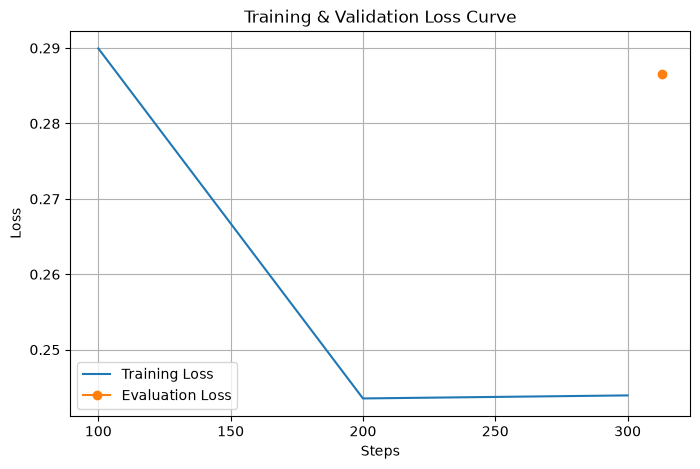

In [207]:
# Extract training and evaluation loss from trainer state
log_history = trainer.state.log_history

train_loss = [x["loss"] for x in log_history if "loss" in x]
train_steps = [x["step"] for x in log_history if "loss" in x]

eval_loss = [x["eval_loss"] for x in log_history if "eval_loss" in x]
eval_steps = [x["step"] for x in log_history if "eval_loss" in x]

plt.figure(figsize=(8, 5))
plt.plot(train_steps, train_loss, label="Training Loss")
if eval_loss:
    plt.plot(eval_steps, eval_loss, label="Evaluation Loss", marker="o")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training & Validation Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

In [208]:
# 1. Run predictions on the test dataset
predictions = trainer.predict(tokenized_datasets["test"])

# 2. Extract predicted class indices (argmax over logits)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

# 3. Print detailed per-class report
target_names = ["World", "Sports", "Business", "Sci/Tech"]
report = classification_report(y_true, y_pred, target_names=target_names, digits=4)

print(report)

              precision    recall  f1-score   support

       World     0.9188    0.9053    0.9120      1900
      Sports     0.9702    0.9768    0.9735      1900
    Business     0.8933    0.8105    0.8499      1900
    Sci/Tech     0.8384    0.9226    0.8785      1900

    accuracy                         0.9038      7600
   macro avg     0.9052    0.9038    0.9035      7600
weighted avg     0.9052    0.9038    0.9035      7600



In [209]:
class SimulatedExpert:
    def __init__(self, target_scores, mode="recall", keyword_rules=None):
        """
        target_scores: dict mapping class_id (0-3) to a float [0.0, 1.0].
                       In 'recall' mode, target_scores[c] = P(predict c | true label is c).
                       In 'precision' mode, target_scores[c] = Precision for class c.
        mode: 'recall' or 'precision'
        keyword_rules: dict mapping keyword string to recall float (e.g., {"ipo": 0.95})
        """
        self.target_scores = target_scores
        self.mode = mode.lower()
        self.keyword_rules = keyword_rules if keyword_rules else {}

    def predict(self, text, true_label):
        text_lower = text.lower()

        # 1. Keyword Recall Overrides (takes precedence if present)
        matching_probs = [
            prob for kw, prob in self.keyword_rules.items() 
            if kw in text_lower
        ]
        if matching_probs and random.random() < max(matching_probs):
            return true_label

        # 2. RECALL Mode Logic
        if self.mode == "recall":
            recall_prob = self.target_scores.get(true_label, 0.5)
            if random.random() < recall_prob:
                return true_label
            else:
                wrong_labels = [c for c in range(4) if c != true_label]
                return random.choice(wrong_labels)

        # 3. PRECISION Mode Logic
        elif self.mode == "precision":
            weights = []
            for candidate_class in range(4):
                precision = self.target_scores.get(candidate_class, 0.5)
                if candidate_class == true_label:
                    weight = precision
                else:
                    weight = 1.0 - precision
                weights.append(weight)

            total_weight = sum(weights)
            if total_weight == 0:
                return random.randint(0, 3)

            probs = [w / total_weight for w in weights]
            return random.choices([0, 1, 2, 3], weights=probs, k=1)[0]

        else:
            raise ValueError(f"Unknown mode '{self.mode}'. Use 'recall' or 'precision'.")

    def evaluate_on_testset(self, test_dataset):
        """Runs the expert across the full test set to compute overall accuracy (Task 2)."""
        correct = sum(
            1 for item in test_dataset 
            if self.predict(item["text"], item["label"]) == item["label"]
        )
        return correct / len(test_dataset)

In [210]:
# Small custom list of common English stop words
STOP_WORDS = {
    'the', 'and', 'for', 'said', 'that', 'with',
    'his', 'was', 'after', 'new', 'its', 'has',
    'will', 'has', 'from', 'are', 'over', 'two',
    'first', 'their', 'have', 'were', 'more',
    'who', 'one', 'but', 'have'
}

def get_top_keywords_per_class(dataset, top_n=20):
    class_names = ["World", "Sports", "Business", "Sci/Tech"]
    class_counters = {0: Counter(), 1: Counter(), 2: Counter(), 3: Counter()}

    # Count word frequencies per class
    for item in dataset["train"]:
        label = item["label"]
        tokens = re.findall(r'\b[a-zA-Z]{3,}\b', item["text"].lower())
        filtered_tokens = [word for word in tokens if word not in STOP_WORDS]
        class_counters[label].update(filtered_tokens)

    # Extract top N keywords per class
    top_words = {}
    for label, counter in class_counters.items():
        top_words[class_names[label]] = [word for word, count in counter.most_common(top_n)]
    
    return top_words

# Usage
top_kw = get_top_keywords_per_class(dataset)
for category, words in top_kw.items():
    print(f"{category}: {words}\n")

World: ['iraq', 'reuters', 'president', 'afp', 'minister', 'killed', 'people', 'government', 'bush', 'quot', 'iraqi', 'prime', 'baghdad', 'monday', 'security', 'wednesday', 'police', 'thursday', 'says', 'nuclear']

Sports: ['game', 'season', 'team', 'win', 'night', 'world', 'out', 'last', 'cup', 'league', 'against', 'year', 'victory', 'this', 'sunday', 'three', 'quot', 'coach', 'when', 'not']

Business: ['reuters', 'oil', 'stocks', 'inc', 'company', 'prices', 'fullquote', 'percent', 'york', 'year', 'corp', 'profit', 'million', 'quarter', 'sales', 'monday', 'billion', 'wednesday', 'tuesday', 'thursday']

Sci/Tech: ['microsoft', 'software', 'reuters', 'internet', 'company', 'space', 'quot', 'this', 'inc', 'search', 'com', 'computer', 'service', 'security', 'music', 'world', 'web', 'year', 'technology', 'online']



In [211]:
# topic accuracy mapping: {0: World, 1: Sports, 2: Business, 3: Sci/Tech}
# base_accs = {0: 0.8, 1: 0.3, 2: 0.9, 3: 0.6}

# # Custom keyword overrides
# keyword_overrides = {
#     "company": 1.0,
#     "inc": 1.0,
#     "world": 1.0,
#     "president": 1.0,
#     "government": 1.0,
#     "iraq": 1.0,
#     "iraqi": 1.0,
# }

expert_test = SimulatedExpert(
    target_scores={0: 0.70, 1: 0.99, 2: 0.40, 3: 0.90},
    mode="precision"
)

# expert = SimulatedExpert(target_scores=base_accs, mode="precision", keyword_rules=keyword_overrides)

# Evaluate stand-alone performance on test set
test_accuracy = expert_test.evaluate_on_testset(dataset["test"])
print(f"Simulated Expert Test Accuracy: {test_accuracy * 100:.2f}%")

Simulated Expert Test Accuracy: 50.14%


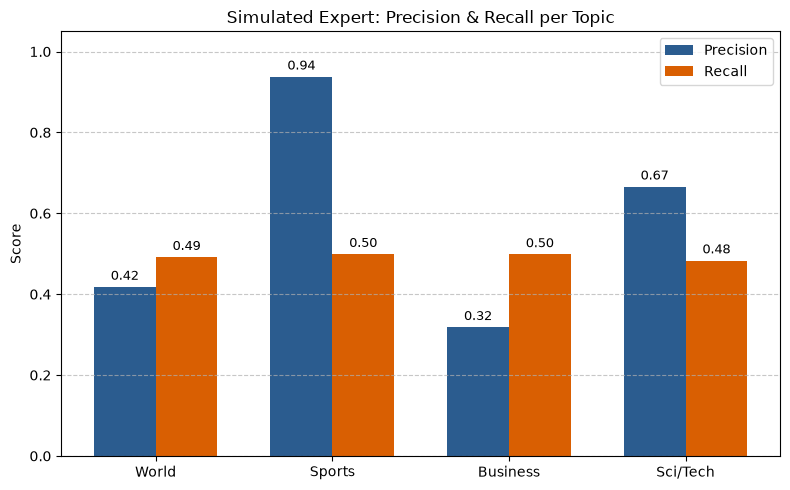

In [212]:
# 1. Collect predictions from expert on the test dataset
y_true = [item["label"] for item in dataset["test"]]
y_pred = [expert_test.predict(item["text"], item["label"]) for item in dataset["test"]]

# 2. Compute classification metrics as a dictionary
target_names = ["World", "Sports", "Business", "Sci/Tech"]
report_dict = classification_report(
    y_true, y_pred, target_names=target_names, output_dict=True
)

# 3. Extract precision and recall values for each category
precision_vals = [report_dict[category]["precision"] for category in target_names]
recall_vals = [report_dict[category]["recall"] for category in target_names]

# 4. Plot side-by-side bar chart
x = np.arange(len(target_names))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, precision_vals, width, label='Precision', color='#2b5c8f')
rects2 = ax.bar(x + width/2, recall_vals, width, label='Recall', color='#d95f02')

ax.set_ylabel('Score')
ax.set_title('Simulated Expert: Precision & Recall per Topic')
ax.set_xticks(x)
ax.set_xticklabels(target_names)
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add exact numeric values above bars
for rect in rects1 + rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [213]:
def extract_probs_and_preds(predictions):
    logits = predictions.predictions
    # Compute Softmax probabilities
    exp_logits = np.exp(logits - np.max(logits, axis=1, keepdims=True))
    probs = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
    confidences = np.max(probs, axis=1, keepdims=True)
    model_preds = np.argmax(probs, axis=1)
    return probs, confidences, model_preds

train_preds = trainer.predict(tokenized_datasets["train"])
test_preds = trainer.predict(tokenized_datasets["test"])

train_probs, train_conf, train_model_preds = extract_probs_and_preds(train_preds)
test_probs, test_conf, test_model_preds = extract_probs_and_preds(test_preds)

y_train = np.array(dataset["train"]["label"])
y_test = np.array(dataset["test"]["label"])

In [214]:
# 2. Instantiate Expert & Generate Predictions
expert = SimulatedExpert(
    target_scores={0: 0.40, 1: 0.98, 2: 0.70, 3: 0.9},
    mode="recall",
    keyword_rules={
        "company": 0.98,
        "inc": 0.98,
        "world": 0.98,
        "president": 0.99,
        "government": 0.99,
        "iraq": 0.99,
        "iraqi": 0.99,
    }
)

m_train = np.array([expert.predict(item["text"], item["label"]) for item in dataset["train"]])
m_test = np.array([expert.predict(item["text"], item["label"]) for item in dataset["test"]])

# 3. Create Training Target for the Deferral Classifier
# Defer (1) if the Expert is CORRECT and the Primary Model is WRONG; else keep model (0)
expert_correct_train = (m_train == y_train)
model_correct_train = (train_model_preds == y_train)

y_defer_train = (expert_correct_train & (~model_correct_train)).astype(int)

# 4. Build Deferral Features (Model Class Probabilities + Max Confidence)
X_defer_train = np.hstack([train_probs, train_conf])
X_defer_test = np.hstack([test_probs, test_conf])

# 5. Train External Deferral Classifier
defer_classifier = LogisticRegression(class_weight="balanced")
defer_classifier.fit(X_defer_train, y_defer_train)

# 6. Inference and Evaluation on Test Set
# Extract probability that deferring is beneficial
defer_probs = defer_classifier.predict_proba(X_defer_test)[:, 1]

# Defer cost (penalty for asking the human)
accuracies = []
coverages = []
costs = []
res = 20
for i in range(res):
    query_cost = 0.0 + 1 * i / res
    costs.append(query_cost)
    defer_decisions = (defer_probs > (0.5 + query_cost)).astype(int)
    final_predictions = np.where(defer_decisions == 1, m_test, test_model_preds)
    coverage = np.mean(defer_decisions == 0)
    system_acc = accuracy_score(y_test, final_predictions)
    
    accuracies.append(system_acc)
    coverages.append(coverage)

query_cost = 0.0

# Only defer if confidence in expert superiority outweighs query cost
defer_decisions = (defer_probs > (0.5 + query_cost)).astype(int)

# Combine outputs based on deferral decisions
final_predictions = np.where(defer_decisions == 1, m_test, test_model_preds)

# Calculate System Performance Metrics
coverage = np.mean(defer_decisions == 0)  # Fraction of predictions made by AI model
system_acc = accuracy_score(y_test, final_predictions)
model_acc = accuracy_score(y_test, test_model_preds)
expert_acc = accuracy_score(y_test, m_test)

print(f"Model Standalone Accuracy:      {model_acc * 100:.2f}%")
print(f"Expert Standalone Accuracy:     {expert_acc * 100:.2f}%")
print(f"Phase 1 Combined System Acc:    {system_acc * 100:.2f}%")
print(f"Model Coverage (Not Deferred): {coverage * 100:.2f}%")

Model Standalone Accuracy:      90.38%
Expert Standalone Accuracy:     85.42%
Phase 1 Combined System Acc:    94.05%
Model Coverage (Not Deferred): 81.70%


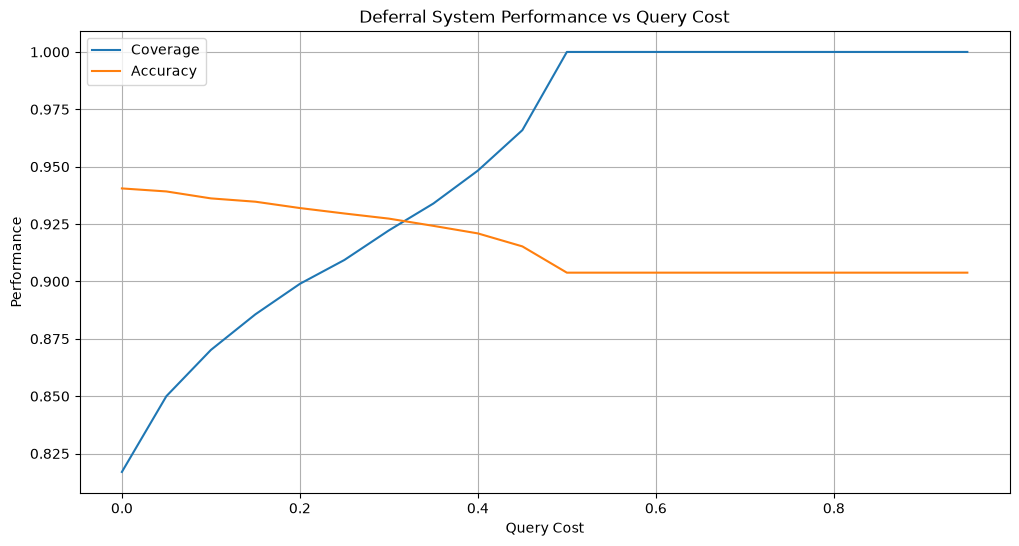

In [215]:
plt.figure(figsize=(12, 6))
plt.plot(costs, coverages)
plt.plot(costs, accuracies)
plt.legend(["Coverage", "Accuracy"])
plt.grid()
plt.xlabel("Query Cost")
plt.ylabel("Performance")
plt.title("Deferral System Performance vs Query Cost")
plt.show()

In [216]:
# Define Expert 1 (Sports & Tech focus)
expert_1 = SimulatedExpert(
    target_scores={0: 0.70, 1: 0.99, 2: 0.40, 3: 0.90},
    mode="precision"
)

# Define Expert 2 (World & Business focus)
expert_2 = SimulatedExpert(
    target_scores={0: 0.95, 1: 0.45, 2: 0.98, 3: 0.60},
    mode="precision"
)

experts = [expert_1, expert_2]
M = len(experts)  # Number of experts = 2
K = 4             # Number of AG News categories
num_labels = K + M # Total logits = 6

# Pre-generate expert predictions for train and test sets
train_expert_preds = np.column_stack([
    [exp.predict(item["text"], item["label"]) for item in dataset["train"]]
    for exp in experts
]) # Shape: (N_train, M)

test_expert_preds = np.column_stack([
    [exp.predict(item["text"], item["label"]) for item in dataset["test"]]
    for exp in experts
])  # Shape: (N_test, M)

In [217]:
# 2. Robust CSSLossTrainer method using safe key extractions
class CostSensitiveL2DTrainer(Trainer):
    def __init__(self, *args, expert_preds_train=None, query_cost=0.001, **kwargs):
        super().__init__(*args, **kwargs)
        self.expert_preds_train = torch.tensor(expert_preds_train, dtype=torch.long)
        self.query_cost = query_cost  # Small tie-breaker penalty
        self.K = 4
        self.M = expert_preds_train.shape[1]
        self.ce_loss = nn.CrossEntropyLoss()

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels", inputs.get("label"))
        idx = inputs.get("idx", None)
        
        model_inputs = {}
        if "input_ids" in inputs:
            model_inputs["input_ids"] = inputs["input_ids"]
        if "attention_mask" in inputs:
            model_inputs["attention_mask"] = inputs["attention_mask"]
            
        outputs = model(**model_inputs)
        logits = outputs.get("logits")  # Shape: (Batch_Size, K + M)
        batch_size = logits.size(0)

        if idx is not None:
            m_batch = self.expert_preds_train[idx.cpu()].to(logits.device)
        else:
            m_batch = torch.zeros((batch_size, self.M), dtype=torch.long, device=logits.device)

        # Build Cost Matrix
        costs = torch.zeros((batch_size, self.K + self.M), device=logits.device)
        
        # Standard classification costs (0 if correct, 1 if wrong)
        for k in range(self.K):
            costs[:, k] = (labels != k).float()
            
        # Expert costs (0 + penalty if correct, 1 + penalty if wrong)
        for m_idx in range(self.M):
            expert_m_preds = m_batch[:, m_idx]
            costs[:, self.K + m_idx] = (labels != expert_m_preds).float() + self.query_cost

        # Select target with lowest total cost
        target_indices = torch.argmin(costs, dim=1)

        # Train with standard Cross-Entropy on optimal targets
        loss = self.ce_loss(logits, target_indices)

        return (loss, outputs) if return_outputs else loss

In [ ]:
# Add sample indices to datasets to track expert predictions in batches
# 1. Add the idx column to your ALREADY TOKENIZED dataset
tokenized_with_idx = tokenized_datasets.map(
    lambda item, idx: {"idx": idx}, 
    with_indices=True
)

# 2. Set format on the tokenized dataset
tokenized_with_idx.set_format(
    type="torch", 
    columns=["input_ids", "attention_mask", "label", "idx"]
)

# Load pretrained model with expanded classification head
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels
)

training_args = TrainingArguments(
    output_dir="./phase2_l2d_model",
    learning_rate=2e-5,
    per_device_train_batch_size=32,  # Increased batch size to speed up further
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="no",
    save_strategy="no",              # Prevents slow disk saving steps
    logging_steps=100
)

trainer_phase2 = CostSensitiveL2DTrainer(
    model=model,
    args=training_args,
    # Apply the same 10,000 sample slice as your original script
    train_dataset=tokenized_with_idx["train"],
    expert_preds_train=train_expert_preds,  # Must slice expert predictions to match!
    query_cost=0.005
)

# Train Phase 2 Model
trainer_phase2.train()

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 24594.25it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
100,0.861943
200,0.408719
300,0.353537


TrainOutput(global_step=313, training_loss=0.5355587188428202, metrics={'train_runtime': 58.4037, 'train_samples_per_second': 171.222, 'train_steps_per_second': 5.359, 'total_flos': 331192120320000.0, 'train_loss': 0.5355587188428202, 'epoch': 1.0})

In [221]:
# 1. Run model inference on test set
raw_test_preds = trainer_phase2.predict(tokenized_with_idx["test"])
logits = raw_test_preds.predictions.copy()  # Shape: (N_test, 6)

# Boost the expert logits slightly at test time
deferral_bias = 2.0  # Adjust between 0.5 and 3.0 to control coverage
logits[:, 4:] += deferral_bias

# Re-run decision rule
decisions = np.argmax(logits, axis=1)

y_test = np.array(dataset["test"]["label"])
final_preds = np.zeros_like(y_test)

ai_predicted = (decisions < 4)
deferred_to_e1 = (decisions == 4)
deferred_to_e2 = (decisions == 5)

final_preds[ai_predicted] = decisions[ai_predicted]
final_preds[deferred_to_e1] = test_expert_preds[deferred_to_e1, 0]
final_preds[deferred_to_e2] = test_expert_preds[deferred_to_e2, 1]

print(f"Overall System Accuracy: {np.mean(final_preds == y_test) * 100:.2f}%")
print(f"AI Coverage (Self-predicted): {np.mean(ai_predicted) * 100:.2f}%")
print(f"Deferred to Expert 1 (Sports/Tech): {np.mean(deferred_to_e1) * 100:.2f}%")
print(f"Deferred to Expert 2 (World/Biz):   {np.mean(deferred_to_e2) * 100:.2f}%")

Overall System Accuracy: 90.09%
AI Coverage (Self-predicted): 100.00%
Deferred to Expert 1 (Sports/Tech): 0.00%
Deferred to Expert 2 (World/Biz):   0.00%
